In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader
from torch import nn
from tm_task_generators import contains_one_task_generator
from tm_interface import TMAgent, TMInterface, TMClass, sample_logits
from reviewer_rl import *
from reviewer_rl_training import train_reviewer, TrainConfig


In [3]:
dataset = torch.load("training_data/1mSmall.pt", weights_only=False)

In [4]:
print(len(dataset))

1000000


In [7]:
debug_file = open("debug.txt", "w+")

for p, s in dataset:
    debug_file.write(f"{str(p)} -> {str(s)}")
    debug_file.write("\n\n")
debug_file.close()

In [5]:
tm_class = TMClass(embed_state_dim=4, max_move=1)
tasks = contains_one_task_generator(8, 512, tm_class)
agent = TMAgent([8, 8, 8], tm_class).to('cuda')
interface = TMInterface(tm_class)
tape, correct_output  = tasks

In [6]:
print(agent.parameters_vector().shape)

torch.Size([279])


In [7]:
rewards = verbose_rollout(agent, tasks, interface, max_depth=10)

 2 |(0)| 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: False
(2)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 1.0 HALTED: True
(0)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(1)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(1)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(1)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(1)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(0)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(0)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True
(1)| 0 | 0 | 0 | 0 | 2 | 2 | 2       REWARD: 0.0 HALTED: True


In [6]:
train_population = create_population(agent, 50000)

In [7]:
train_scores = score_population_compiled(train_population, tasks, interface, slice_size=1000)

W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401] [__cudagraphs] skipping cudagraphs due to mutated inputs (1 instances). Found from : 
W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401] [__cudagraphs]    File "/home/mxmlabserver/Desktop/JPKWork/ReviewerBasedRL/reviewer_rl.py", line 70, in torch_dynamo_resume_in_fast_rollout_at_63
W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401] [__cudagraphs]     agent_state, world_state, reward, terminal = interface.take_action(logits, agent_state, world_state)
W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401] [__cudagraphs]                                                  ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401] [__cudagraphs]   File "/home/mxmlabserver/Desktop/JPKWork/ReviewerBasedRL/tm_interface.py", line 49, in take_action
W0929 12:20:12.621000 169577 torch/_inductor/cudagraph_utils.py:401

In [9]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.99, 0.01])

In [10]:
print(len(train_dataset))
print(len(test_dataset))

990000
10000


In [11]:
reviewer = Reviewer(agent.parameters_vector()).to('cuda')

In [31]:
param_count = sum(p.numel() for p in reviewer.parameters())

for p in reviewer.parameters():
    print(p)

print(param_count)

Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1.

In [12]:
print(len(train_dataset))

990000


In [18]:
train_p_mean = train_dataset.agent_params.mean().item()
train_p_std = train_dataset.agent_params.std(dim=1)
train_s_mean = train_dataset.agent_scores.mean().item()
train_s_std = train_dataset.agent_scores.std().item()

test_p_mean = test_dataset.agent_params.mean().item()
test_p_std = test_dataset.agent_params.std(dim=1)
test_s_mean = test_dataset.agent_scores.mean().item()
test_s_std = test_dataset.agent_scores.std().item()

#print("TRAINIG", "mean", "".join([f"{p.item():.6f}" for p in train_p_mean[:10]]), "std", "".join([f"{p.item():.6f}" for p in train_p_std[:10]]))
print(f"TRAINING p_mean {train_p_mean:.6f} p_std X s_mean {train_s_mean:.6f} s_std {train_s_std:.6f}")
print(f"TESTING p_mean {test_p_mean:.6f} p_std X s_mean {test_s_mean:.6f} s_std {test_s_std:.6f}")

print(" ".join([f"{v.item():.6f}" for v in train_p_std[:10]]))
print(" ".join([f"{v.item():.6f}" for v in test_p_std[:10]]))

AttributeError: 'Subset' object has no attribute 'agent_params'

In [13]:
train_config = TrainConfig(epochs=200, early_stopping_patience=200)
print(train_config)

TrainConfig(epochs=200, batch_size=128, lr=0.0003, weight_decay=0.01, warmup_epochs=5, grad_clip_norm=1.0, val_fraction=0.1, early_stopping_patience=200, use_amp=True, num_workers=0, device=None, log_every=1)


In [14]:
results, last_state = train_reviewer(reviewer, train_dataset, test_dataset, config=train_config)

epoch    1/200 | train_loss 0.9970 | val_loss 0.9869 | lr 6.00e-05
epoch    2/200 | train_loss 0.9768 | val_loss 0.9859 | lr 1.20e-04
epoch    3/200 | train_loss 0.9742 | val_loss 0.9879 | lr 1.80e-04
epoch    4/200 | train_loss 0.9714 | val_loss 0.9881 | lr 2.40e-04
epoch    5/200 | train_loss 0.9680 | val_loss 0.9907 | lr 3.00e-04
epoch    6/200 | train_loss 0.9630 | val_loss 0.9951 | lr 3.00e-04
epoch    7/200 | train_loss 0.9539 | val_loss 1.0026 | lr 3.00e-04
epoch    8/200 | train_loss 0.9435 | val_loss 1.0068 | lr 3.00e-04
epoch    9/200 | train_loss 0.9323 | val_loss 1.0224 | lr 3.00e-04
epoch   10/200 | train_loss 0.9226 | val_loss 1.0203 | lr 3.00e-04
epoch   11/200 | train_loss 0.9133 | val_loss 1.0233 | lr 2.99e-04
epoch   12/200 | train_loss 0.9049 | val_loss 1.0461 | lr 2.99e-04
epoch   13/200 | train_loss 0.8968 | val_loss 1.0373 | lr 2.99e-04
epoch   14/200 | train_loss 0.8892 | val_loss 1.0592 | lr 2.98e-04
epoch   15/200 | train_loss 0.8825 | val_loss 1.0584 | lr 2.98

In [15]:
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=False, drop_last=True,
)
print(len(test_loader))

criterion = torch.nn.MSELoss()

running_loss = 0.0
for p, score in test_loader:
    pred = reviewer(p)
    loss = criterion(pred, score)
    running_loss += loss
    print("True Score:", float(score.item()), "Pred Score:", float(pred.item()), "Loss:", float(loss.item()))
mean_loss = running_loss/len(test_loader)
print(f"Mean Loss: {mean_loss:.6f}")

10000
True Score: 1.1108827590942383 Pred Score: 0.08654937893152237 Loss: 1.049258828163147
True Score: -0.6458528637886047 Pred Score: -0.35344716906547546 Loss: 0.08550108969211578
True Score: 0.8473724126815796 Pred Score: -0.16742271184921265 Loss: 1.0298089981079102
True Score: 0.49602529406547546 Pred Score: -0.27845239639282227 Loss: 0.5998157262802124
True Score: 0.23251496255397797 Pred Score: -0.005500774830579758 Loss: 0.05665149167180061
True Score: -1.348547101020813 Pred Score: 0.07513883709907532 Loss: 2.026881456375122
True Score: -0.030995381996035576 Pred Score: -0.2830430567264557 Loss: 0.06352803856134415
True Score: 0.49602529406547546 Pred Score: -0.32241126894950867 Loss: 0.6698384284973145
True Score: 0.8473724126815796 Pred Score: 0.027937673032283783 Loss: 0.6714733242988586
True Score: -0.2066689431667328 Pred Score: -0.1249622330069542 Loss: 0.00667598657310009
True Score: -0.6458528637886047 Pred Score: 0.16216304898262024 Loss: 0.6528897881507874
True Sco

/home/mxmlabserver/Desktop/JPKWork/ReviewerBasedRL/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


True Score: -1.6120574474334717 Pred Score: -0.18689629435539246 Loss: 2.0310842990875244
True Score: 1.0230460166931152 Pred Score: 0.2001326084136963 Loss: 0.6771864891052246
True Score: -1.0850367546081543 Pred Score: 0.0185786634683609 Loss: 1.217966914176941
True Score: -0.9971999526023865 Pred Score: -0.23966357111930847 Loss: 0.5738614201545715
True Score: 1.6379034519195557 Pred Score: -0.05223400145769119 Loss: 2.85656476020813
True Score: -0.38234251737594604 Pred Score: 0.2008717954158783 Loss: 0.34013891220092773
True Score: 1.9014137983322144 Pred Score: -0.12396617233753204 Loss: 4.102163791656494
True Score: -0.11883216351270676 Pred Score: -0.004415430128574371 Loss: 0.013091188855469227
True Score: -0.2066689431667328 Pred Score: -0.090668685734272 Loss: 0.013456059619784355
True Score: 0.23251496255397797 Pred Score: 0.06519626826047897 Loss: 0.027995547279715538
True Score: -0.5580160617828369 Pred Score: 0.302116721868515 Loss: 0.7398284673690796
True Score: -0.7336

In [17]:
import matplotlib.pyplot as plt

3.8338229656219482 0.19225847721099854


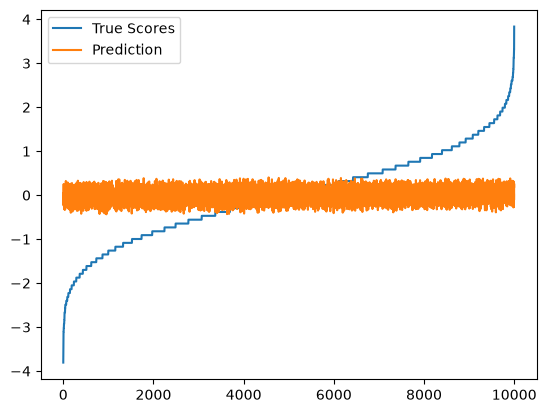

In [18]:
test_data = [(p, score) for p, score in test_loader]
test_data.sort(key=lambda el: el[1])
scores = [score.item() for _, score in test_data]
preds = [reviewer(p).item() for p, _ in test_data]

print(scores[-1], preds[-1])
plt.plot(scores, label="True Scores")
plt.plot(preds, label="Prediction")
plt.legend()
plt.show()